# Counting Agent

Notebook 02 trainiert einen Count-aware-Agenten auf derselben Umgebung wie Notebook 01 und speichert ihn fuer Notebook 03.

## Creating the Agent

In [4]:
from collections import defaultdict
from pathlib import Path
import pickle
import sys

import gymnasium as gym
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "blackjack_env.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from blackjack_env import BlackjackEnv


def counting_state_key(obs: np.ndarray) -> tuple[int, int, int, int, int, int]:
    player_total, dealer_upcard, usable_ace, running_count, true_count, cards_remaining = obs
    count_bucket = int(np.clip(np.round(running_count), -20, 20))
    true_count_bucket = int(np.clip(np.round(true_count), -10, 10))
    shoe_bucket = int(np.clip(np.round(cards_remaining / 52.0), 0, 6))
    return (
        int(player_total),
        int(dealer_upcard),
        int(usable_ace),
        count_bucket,
        true_count_bucket,
        shoe_bucket,
    )


class CountingBlackjackAgent:
    def __init__(
        self,
        env: gym.Env,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float = 0.95,
    ):
        """Initialize a Q-learning agent that can use count information."""
        self.env = env
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))
        self.lr = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.training_error = []

    def get_action(self, obs: np.ndarray) -> int:
        state = counting_state_key(obs)
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        return int(np.argmax(self.q_values[state]))

    def update(
        self,
        obs: np.ndarray,
        action: int,
        reward: float,
        terminated: bool,
        next_obs: np.ndarray,
    ):
        state = counting_state_key(obs)
        next_state = counting_state_key(next_obs)
        future_q_value = (not terminated) * np.max(self.q_values[next_state])
        target = reward + self.discount_factor * future_q_value
        temporal_difference = target - self.q_values[state][action]
        self.q_values[state][action] += self.lr * temporal_difference
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)


def save_agent_artifact(agent, env, artifact_path: Path, label: str):
    artifact_path.parent.mkdir(parents=True, exist_ok=True)
    artifact = {
        "label": label,
        "state_keys": list(agent.q_values.keys()),
        "q_values": {state: values.copy() for state, values in agent.q_values.items()},
        "training_error": list(agent.training_error),
        "episode_returns": list(env.return_queue),
        "episode_lengths": list(env.length_queue),
        "learning_rate": agent.lr,
        "discount_factor": agent.discount_factor,
    }
    with artifact_path.open("wb") as file_handle:
        pickle.dump(artifact, file_handle)


MODEL_PATH = PROJECT_ROOT / "models" / "counting_agent.pkl"

## Training the Agent

In [5]:
learning_rate = 0.01
n_episodes = 300_000
start_epsilon = 1.0
final_epsilon = 0.1
epsilon_decay = (start_epsilon - final_epsilon) / (n_episodes * 0.6)
base_seed = 42

base_env = BlackjackEnv(num_decks=6, penetration=0.75, stand_on_soft_17=True)
base_env.action_space.seed(base_seed)
env = gym.wrappers.RecordEpisodeStatistics(base_env, buffer_length=n_episodes)

np.random.seed(base_seed)

agent = CountingBlackjackAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

### The Training Loop

In [6]:
from tqdm import tqdm

for episode in tqdm(range(n_episodes)):
    obs, info = env.reset(seed=base_seed + episode)
    done = False

    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        agent.update(obs, action, reward, terminated, next_obs)
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()

100%|██████████| 300000/300000 [00:55<00:00, 5416.40it/s]


### Analyzing Training Results

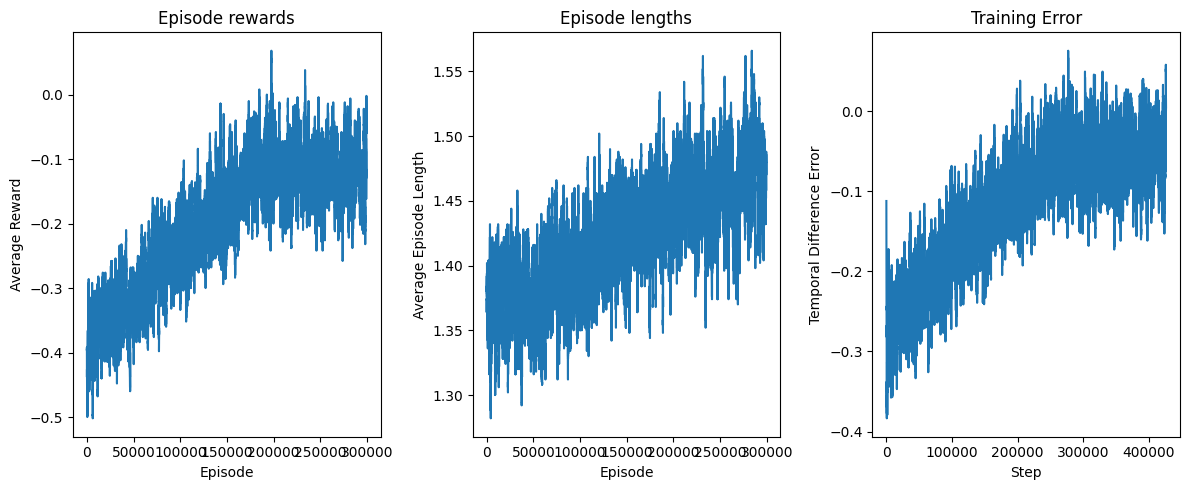

In [7]:
from matplotlib import pyplot as plt


def get_moving_avgs(arr, window, convolution_mode):
    """Compute a moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode,
    ) / window


rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(env.return_queue, rolling_length, "valid")
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(env.length_queue, rolling_length, "valid")
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(agent.training_error, rolling_length, "same")
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()

## Saving the Trained Agent

In [8]:
save_agent_artifact(agent, env, MODEL_PATH, label="counting")
print(f"Saved counting agent to {MODEL_PATH}")

Saved counting agent to E:\tomni\Documents\01_Code\ml-blackjack\models\counting_agent.pkl
